<a href="https://www.kaggle.com/code/sakethyalamanchili/multiclass-health-prediction-model?scriptVersionId=253217885" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import xgboost
import lightgbm
import catboost
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [9]:
data = pd.read_csv("/kaggle/input/healthcare-dataset/healthcare_dataset.csv")
data

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [10]:
data = data.drop(columns=['Name'])
data

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 55500 non-null  int64  
 1   Gender              55500 non-null  object 
 2   Blood Type          55500 non-null  object 
 3   Medical Condition   55500 non-null  object 
 4   Date of Admission   55500 non-null  object 
 5   Doctor              55500 non-null  object 
 6   Hospital            55500 non-null  object 
 7   Insurance Provider  55500 non-null  object 
 8   Billing Amount      55500 non-null  float64
 9   Room Number         55500 non-null  int64  
 10  Admission Type      55500 non-null  object 
 11  Discharge Date      55500 non-null  object 
 12  Medication          55500 non-null  object 
 13  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(11)
memory usage: 5.9+ MB


In [12]:
data["Date of Admission"] = pd.to_datetime(data["Date of Admission"], errors='coerce')
data["Discharge Date"] = pd.to_datetime(data["Discharge Date"], errors='coerce')

data["Length of Stay"] = data["Discharge Date"] - data["Date of Admission"]

data["Length of Stay (Days)"] = data["Length of Stay"].dt.days

data = data.drop(columns=['Length of Stay'])

data

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay (Days)
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal,30
55496,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal,9
55497,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal,28
55498,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal,6


In [13]:
data.isna().sum()

Age                      0
Gender                   0
Blood Type               0
Medical Condition        0
Date of Admission        0
Doctor                   0
Hospital                 0
Insurance Provider       0
Billing Amount           0
Room Number              0
Admission Type           0
Discharge Date           0
Medication               0
Test Results             0
Length of Stay (Days)    0
dtype: int64

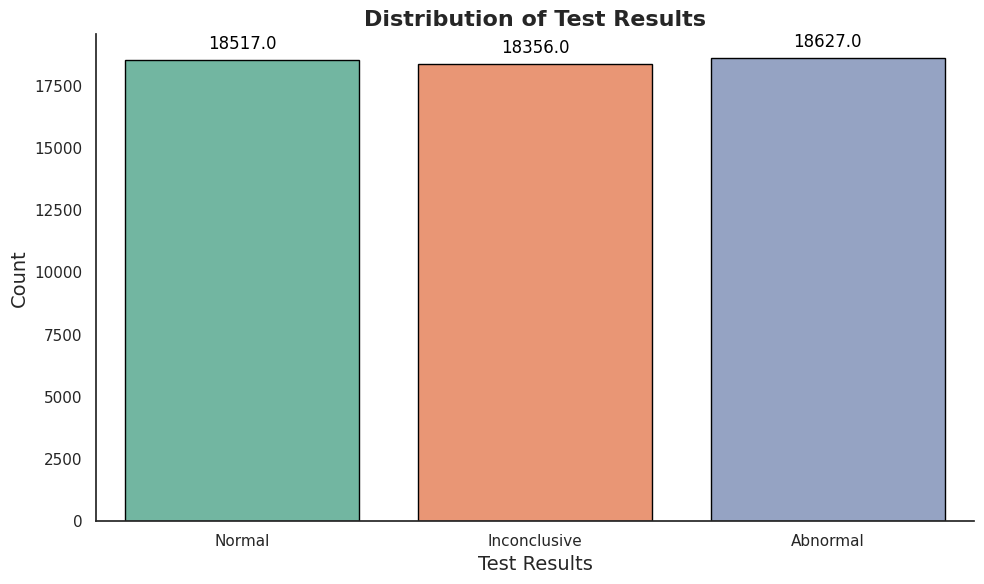

In [14]:
sns.set(style="white", palette="pastel")

plt.figure(figsize=(10, 6))

ax = sns.countplot(data=data, x='Test Results', palette='Set2', edgecolor='black')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title("Distribution of Test Results", fontsize=16, fontweight='bold')
plt.xlabel("Test Results", fontsize=14)
plt.ylabel("Count", fontsize=14)

sns.despine()

plt.tight_layout()
plt.show()

This visualization shows that the dataset is relatively balanced across the three classes, with a slight dominace of "Normal" results. This means we can train a model without needing heavy resampling or class rebalancing. ***Accuracy will be a reliable evaluation metric.***

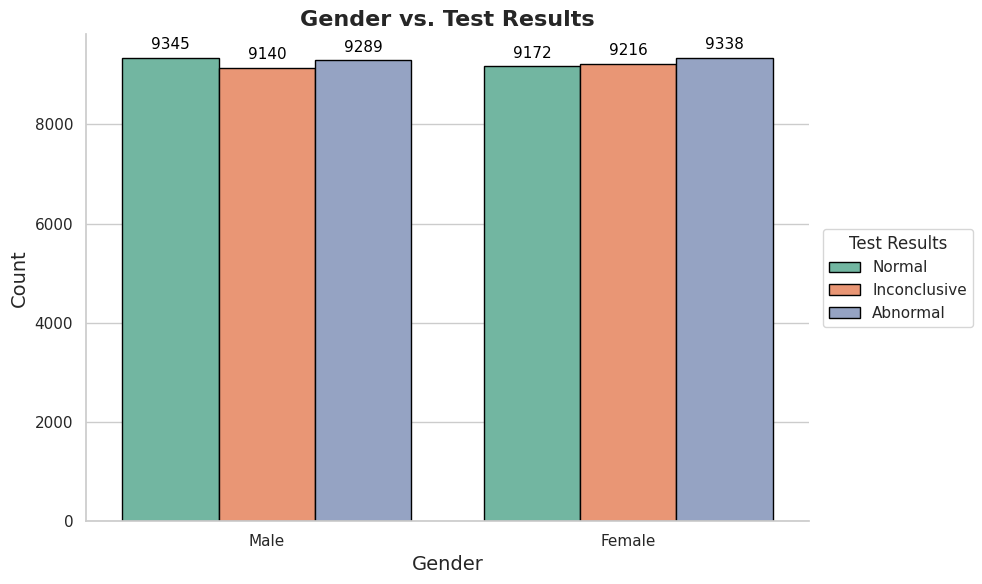

In [15]:
sns.set(style="whitegrid", palette="pastel")
plt.figure(figsize=(10, 6))

ax = sns.countplot(data=data, x="Gender", hue="Test Results", palette="Set2", edgecolor='black')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, color='black', xytext=(0, 4),
                    textcoords='offset points')

plt.title("Gender vs. Test Results", fontsize=16, fontweight='bold')
plt.xlabel("Gender", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.legend(title='Test Results', title_fontsize=12, fontsize=11, 
           loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

sns.despine()

plt.tight_layout()

plt.show()

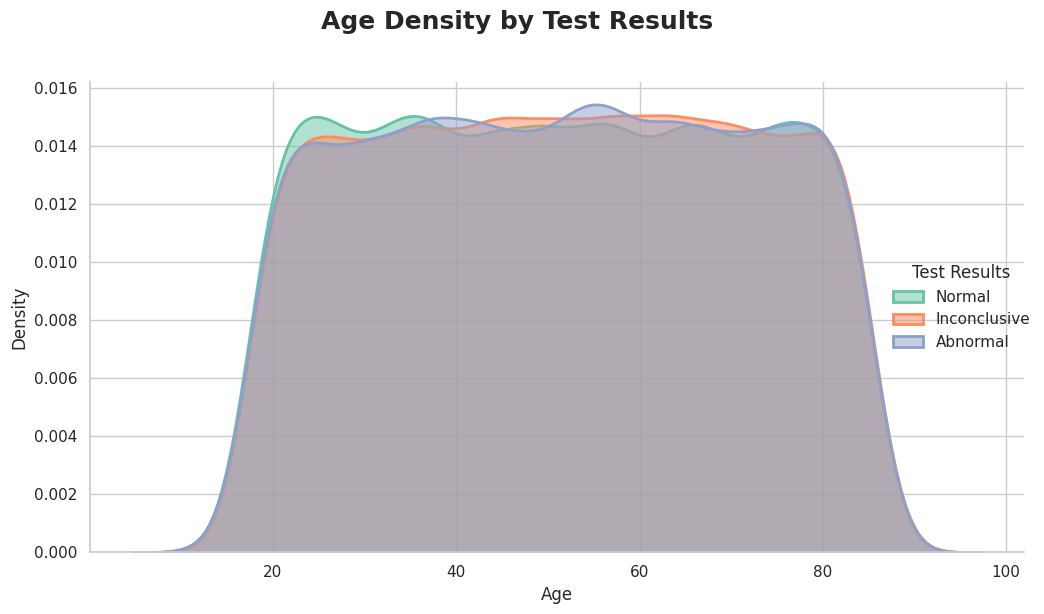

In [16]:
g = sns.FacetGrid(data, hue="Test Results", height=6, aspect=1.5, palette='Set2')
g.map(sns.kdeplot, "Age", fill=True, alpha=0.5, linewidth=2)
g.add_legend(title="Test Results")
g.set_axis_labels("Age", "Density")
g.fig.suptitle("Age Density by Test Results", fontsize=18, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

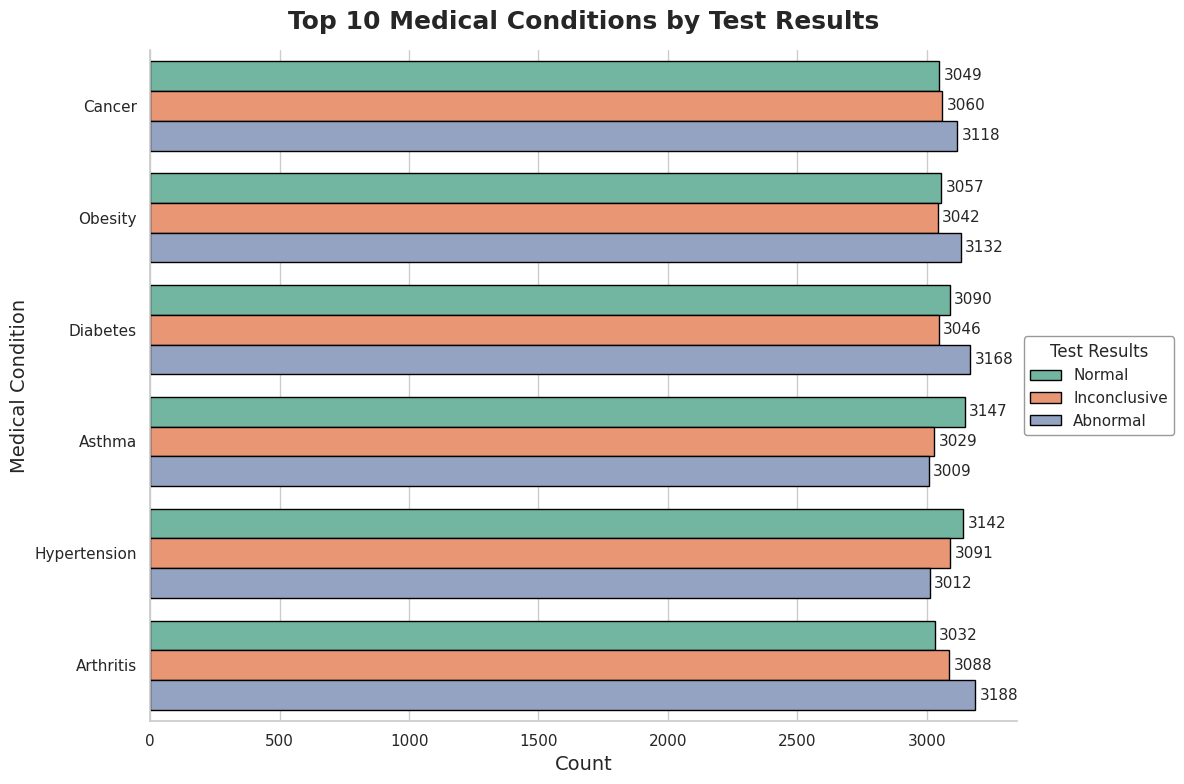

In [17]:
sns.set_theme(style="whitegrid")

top_conditions = data['Medical Condition'].value_counts().nlargest(10).index
filtered_data = data[data['Medical Condition'].isin(top_conditions)]

plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=filtered_data,
    y='Medical Condition',
    hue='Test Results',
    palette='Set2',
    edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=11, padding=3)

plt.title('Top 10 Medical Conditions by Test Results', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Medical Condition', fontsize=14)

plt.legend(
    title='Test Results',
    title_fontsize=12,
    fontsize=11,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

sns.despine()
plt.tight_layout()

plt.show()

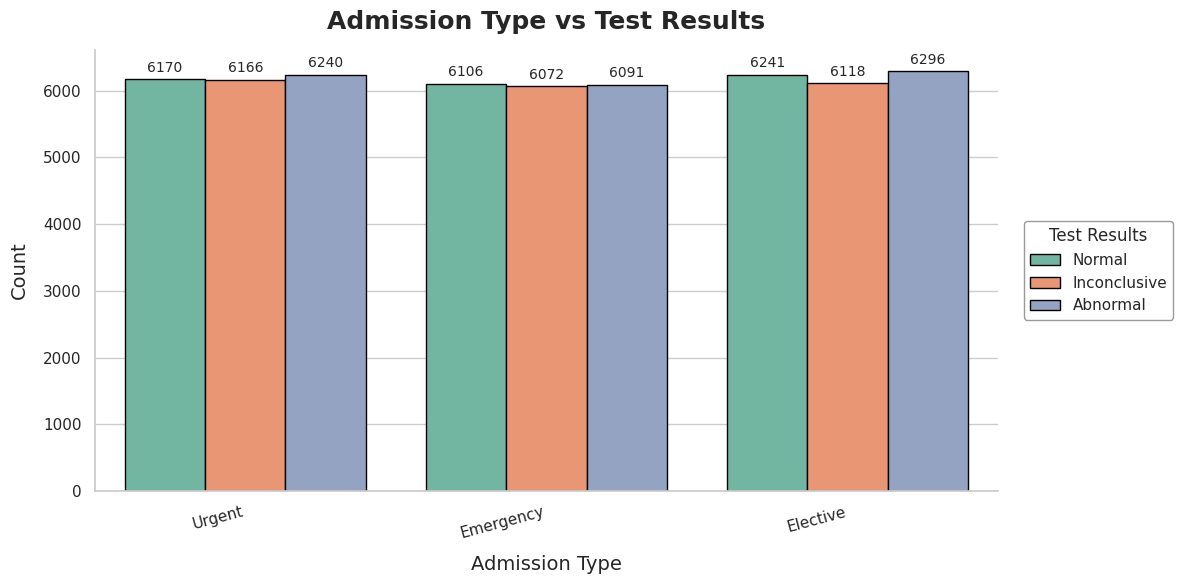

In [18]:
data['Test Results'] = data['Test Results'].astype(str)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=data,
    x='Admission Type',
    hue='Test Results',
    palette='Set2',
    edgecolor='black'
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title('Admission Type vs Test Results', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Admission Type', fontsize=14, labelpad=10)
plt.ylabel('Count', fontsize=14, labelpad=10)

plt.legend(
    title='Test Results',
    title_fontsize=12,
    fontsize=11,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

sns.despine()
plt.tight_layout()

plt.show()

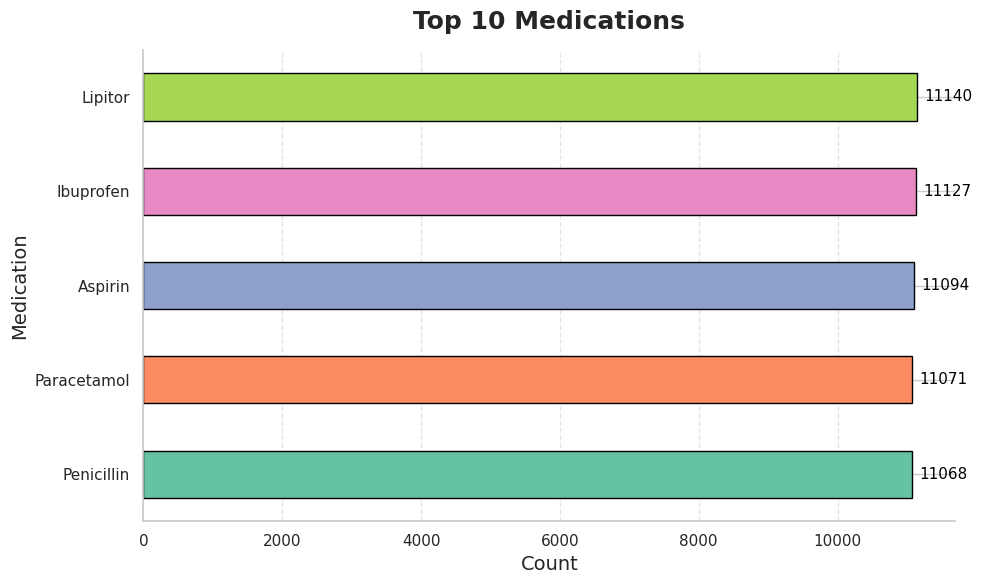

In [19]:
top_meds = data['Medication'].value_counts().nlargest(10)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = top_meds.sort_values().plot(
    kind='barh',
    color=sns.color_palette("Set2", n_colors=10),
    edgecolor='black'
)

for i, v in enumerate(top_meds.sort_values()):
    ax.text(v + max(top_meds)*0.01, i, str(v), color='black', va='center', fontsize=11)

plt.title('Top 10 Medications', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Medication', fontsize=14)

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

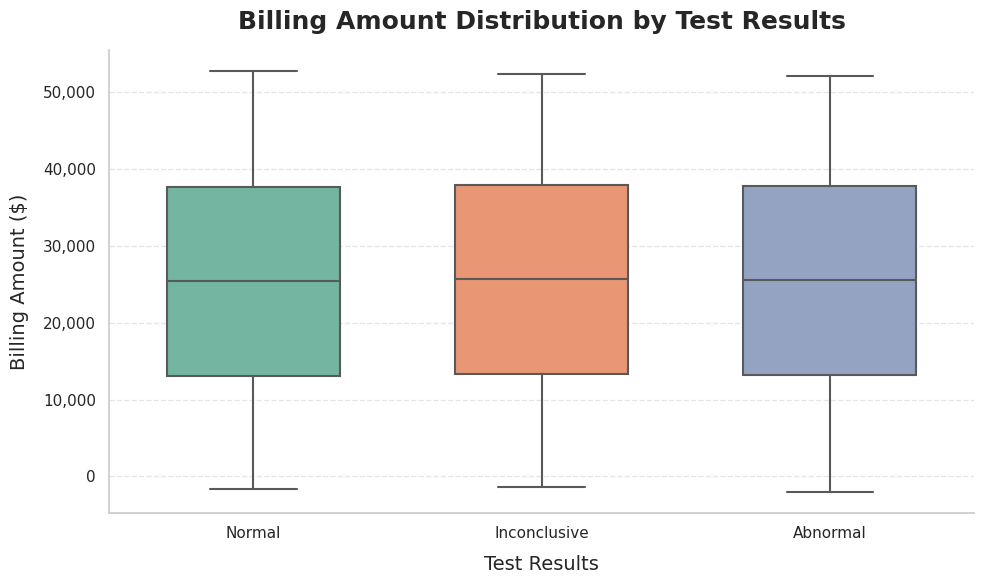

In [20]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=data,
    x='Test Results',
    y='Billing Amount',
    palette='Set2',
    width=0.6,
    linewidth=1.5,
    fliersize=3  
)

plt.title('Billing Amount Distribution by Test Results', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Test Results', fontsize=14, labelpad=10)
plt.ylabel('Billing Amount ($)', fontsize=14, labelpad=10)

ax.set_yticklabels([f'{int(tick):,}' for tick in ax.get_yticks().tolist()])

sns.despine()

ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)

plt.tight_layout()

plt.show()

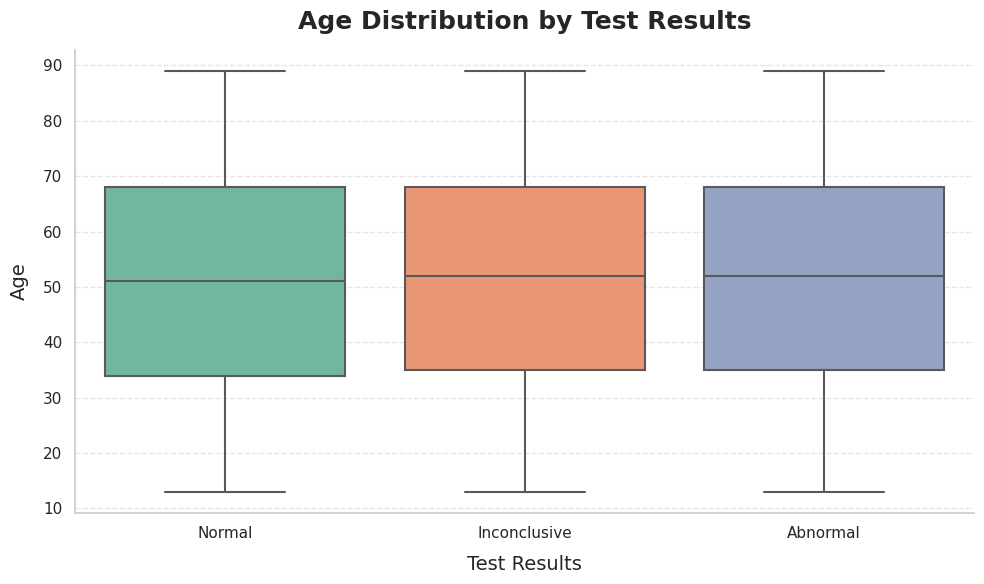

In [21]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=data,
    x='Test Results',
    y='Age',
    palette='Set2',
    linewidth=1.5,
    fliersize=3  
)

plt.title('Age Distribution by Test Results', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Test Results', fontsize=14, labelpad=10)
plt.ylabel('Age', fontsize=14, labelpad=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)

sns.despine()
plt.tight_layout()
plt.show()

In [23]:
target_feature = data['Test Results']
data = data.drop('Test Results', axis=1)
data

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Length of Stay (Days)
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,2
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,6
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,15
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,30
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,30
55496,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,9
55497,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,28
55498,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,6


In [24]:
categorical_features = []
numerical_features = []

for feature in data.columns:
    if data[feature].nunique() < 10:
        categorical_features.append(feature)
    else:
        numerical_features.append(feature)

In [25]:
categorical_features

['Gender',
 'Blood Type',
 'Medical Condition',
 'Insurance Provider',
 'Admission Type',
 'Medication']

In [26]:
numerical_features

['Age',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Billing Amount',
 'Room Number',
 'Discharge Date',
 'Length of Stay (Days)']

In [27]:
for feature in numerical_features:
    if data[feature].dtype == 'object':
        print(f"{feature} column needs encoding")

Doctor column needs encoding
Hospital column needs encoding


In [28]:
# Frequency Encoding for Doctor
doctor_freq = data["Doctor"].value_counts().to_dict()
data["Doctor_Encoded"] = data["Doctor"].map(doctor_freq)

# Frequency Encoding for Hospital
hospital_freq = data["Hospital"].value_counts().to_dict()
data["Hospital_Encoded"] = data["Hospital"].map(hospital_freq)

In [29]:
data = data.drop(columns=["Doctor", "Hospital"])
data

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Length of Stay (Days),Doctor_Encoded,Hospital_Encoded
0,30,Male,B-,Cancer,2024-01-31,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,2,17,7
1,62,Male,A+,Obesity,2019-08-20,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,6,1,6
2,76,Female,A-,Obesity,2022-09-22,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,15,1,4
3,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,30,1,1
4,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,20,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,Female,O+,Asthma,2020-08-16,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,30,2,2
55496,61,Female,AB-,Obesity,2020-01-23,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,9,2,2
55497,38,Female,B+,Hypertension,2020-07-13,UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,28,2,2
55498,43,Male,O-,Arthritis,2019-05-25,Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,6,2,2


In [30]:
data['Admission_Year'] = data['Date of Admission'].dt.year
data['Admission_Month'] = data['Date of Admission'].dt.month
data['Admission_Day'] = data['Date of Admission'].dt.day

data = data.drop(['Date of Admission'], axis=1)

data['Discharge_Year'] = data['Discharge Date'].dt.year
data['Discharge_Month'] = data['Discharge Date'].dt.month
data['Discharge_Day'] = data['Discharge Date'].dt.day

data = data.drop(['Discharge Date'], axis=1)

In [31]:
data = pd.get_dummies(data, columns=categorical_features, drop_first=True, dtype=int)
data

,Age,Billing Amount,Room Number,Length of Stay (Days),Doctor_Encoded,Hospital_Encoded,Admission_Year,Admission_Month,Admission_Day,Discharge_Year,...,Insurance Provider_Blue Cross,Insurance Provider_Cigna,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Emergency,Admission Type_Urgent,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,30,18856.281306,328,2,17,7,2024,1,31,2024,...,1,0,0,0,0,1,0,0,1,0
1,62,33643.327287,265,6,1,6,2019,8,20,2019,...,0,0,1,0,1,0,1,0,0,0
2,76,27955.096079,205,15,1,4,2022,9,22,2022,...,0,0,0,0,1,0,0,0,0,0
3,28,37909.782410,450,30,1,1,2020,11,18,2020,...,0,0,1,0,0,0,1,0,0,0
4,43,14238.317814,458,20,2,2,2022,9,19,2022,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,2650.714952,417,30,2,2,2020,8,16,2020,...,1,0,0,0,0,0,0,0,0,1
55496,61,31457.797307,316,9,2,2,2020,1,23,2020,...,0,1,0,0,0,0,0,0,0,0
55497,38,27620.764717,347,28,2,2,2020,7,13,2020,...,0,0,0,1,0,1,1,0,0,0
55498,43,32451.092358,321,6,2,2,2019,5,25,2019,...,0,0,1,0,0,0,1,0,0,0


In [32]:
le = LabelEncoder()
target_feature = le.fit_transform(target_feature)
target_feature = pd.DataFrame(target_feature, columns=["Test Results"])
target_feature

,Test Results
0,2
1,1
2,2
3,0
4,0
...,...
55495,0
55496,2
55497,0
55498,0


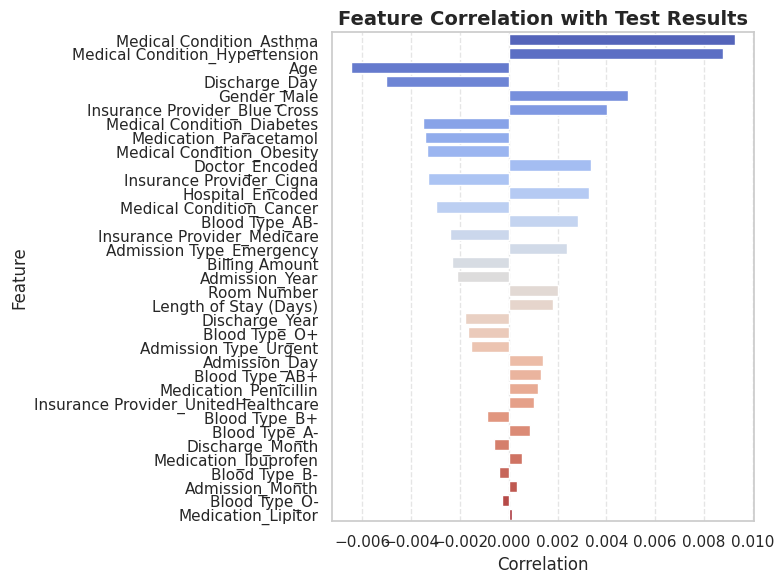

In [33]:
# Make sure target_feature has a name
target_feature.name = 'Test Results'

# Combine data and target
data_corr = pd.concat([data, target_feature], axis=1)

# Compute correlation with the target only
target_corr = data_corr.corr()['Test Results'].drop('Test Results').sort_values(key=abs, ascending=False)

# Plot top correlations with the target
plt.figure(figsize=(8, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")

plt.title(f'Feature Correlation with {target_feature.name}', fontsize=14, fontweight='bold')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(data, target_feature, random_state=42, test_size=0.2)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (44400, 35)
Shape of X_test: (11100, 35)
Shape of y_train: (44400, 1)
Shape of y_test: (11100, 1)


In [35]:
models = {
    "LogisticRegression": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(),
    "LightGBM": LGBMClassifier(),
    "SVM": SVC(),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier()
}

In [36]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == "CatBoost":
        model.fit(X_train, y_train, verbose=0)  # CatBoost is noisy
    else:
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        "Accuracy": acc,
        "Classification Report": classification_report(y_test, y_pred, output_dict=True),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }
    
    print(f"{name} Accuracy: {acc:.4f}")

accuracy_df = pd.DataFrame({k: v["Accuracy"] for k, v in results.items()}, index=["Accuracy"]).T.sort_values(by="Accuracy", ascending=False)
print("\nModel Performance Summary:")
display(accuracy_df)

Training LogisticRegression...
LogisticRegression Accuracy: 0.3369
Training DecisionTree...
DecisionTree Accuracy: 0.4199
Training RandomForest...
RandomForest Accuracy: 0.4412
Training XGBoost...
XGBoost Accuracy: 0.3817
Training CatBoost...
CatBoost Accuracy: 0.3853
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 44400, number of used features: 35
[LightGBM] [Info] Start training from score -1.093692
[LightGBM] [Info] Start training from score -1.102742
[LightGBM] [Info] Start training from score -1.099423
LightGBM Accuracy: 0.3743
Training SVM...
SVM Accuracy: 0.3336
Training AdaBoost...
AdaBoost Accuracy: 0.3389
Traini

,Accuracy
RandomForest,0.441171
DecisionTree,0.419910
CatBoost,0.385315
XGBoost,0.381712
LightGBM,0.374324
GradientBoosting,0.341622
AdaBoost,0.338919
LogisticRegression,0.336937
SVM,0.333604


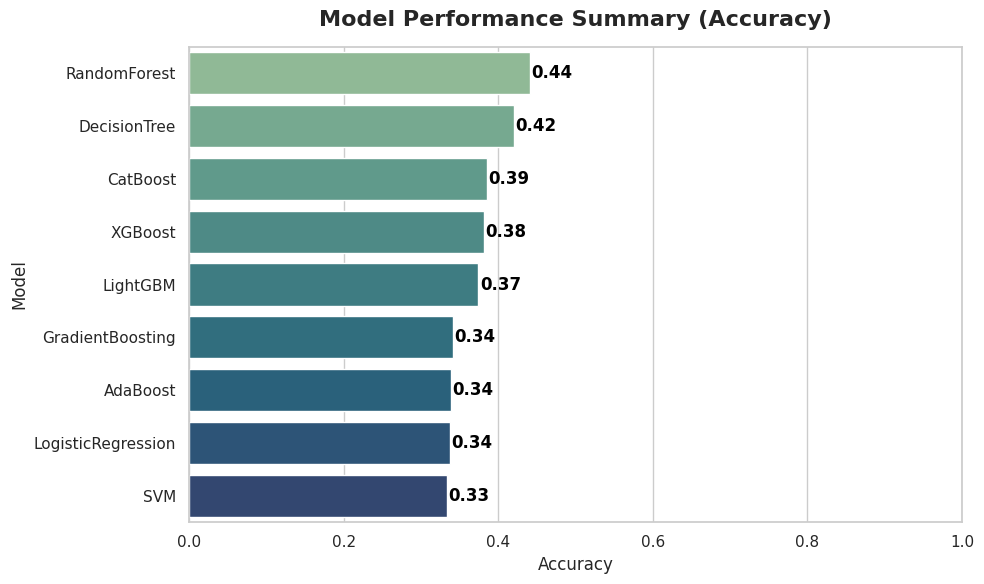

In [37]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

bar = sns.barplot(
    x="Accuracy", 
    y=accuracy_df.index, 
    data=accuracy_df.reset_index(), 
    palette="crest"
)

for i, v in enumerate(accuracy_df["Accuracy"]):
    bar.text(v + 0.002, i, f"{v:.2f}", color='black', va='center', fontweight='bold')

plt.title("Model Performance Summary (Accuracy)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Accuracy", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.xlim(0, 1)  

plt.tight_layout()
plt.show()

In [38]:
for model_name, model in models.items():
    print("="*60)
    print(f"Model: {model_name}")
    print("="*60)
    
    # Accuracy
    acc = results[model_name]["Accuracy"]
    print(f"Accuracy: {acc:.4f}\n")
    
    # Classification Report
    print("Classification Report:")
    report_df = pd.DataFrame(results[model_name]["Classification Report"]).transpose()
    display(report_df.round(2))
    
    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = results[model_name]["Confusion Matrix"]
    cm_df = pd.DataFrame(cm, 
                         index=[f"Actual {label}" for label in np.unique(y_test)],
                         columns=[f"Predicted {label}" for label in np.unique(y_test)])
    display(cm_df)
    print("\n")

Model: LogisticRegression
Accuracy: 0.3369

Classification Report:


,precision,recall,f1-score,support
0,0.34,0.32,0.33,3754.00
1,0.33,0.27,0.30,3617.00
2,0.34,0.42,0.37,3729.00
accuracy,0.34,0.34,0.34,0.34
macro avg,0.34,0.34,0.33,11100.00
weighted avg,0.34,0.34,0.33,11100.00



Confusion Matrix:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,1205,1006,1543
Actual 1,1137,980,1500
Actual 2,1166,1008,1555




Model: DecisionTree
Accuracy: 0.4199

Classification Report:


...

,Predicted 0,Predicted 1,Predicted 2
Actual 0,1191,1361,1202
Actual 1,1131,1341,1145
Actual 2,1132,1367,1230




Model: GradientBoosting
Accuracy: 0.3416

Classification Report:


,precision,recall,f1-score,support
0,0.34,0.35,0.35,3754.00
1,0.34,0.37,0.36,3617.00
2,0.34,0.30,0.32,3729.00
accuracy,0.34,0.34,0.34,0.34
macro avg,0.34,0.34,0.34,11100.00
weighted avg,0.34,0.34,0.34,11100.00



Confusion Matrix:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,1328,1296,1130
Actual 1,1210,1344,1063
Actual 2,1312,1297,1120


In [39]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model_1.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  
    optimizer=tf.keras.optimizers.Adam(),                  
    metrics=['accuracy']                                   
)

history_1 = model_1.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))  

Epoch 1/100


2025-07-30 00:42:22.469019: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1388/1388 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3372 - loss: 45.1285 - val_accuracy: 0.3382 - val_loss: 1.0990
Epoch 2/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3341 - loss: 1.0988 - val_accuracy: 0.3382 - val_loss: 1.0986
Epoch 3/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3343 - loss: 1.0986 - val_accuracy: 0.3382 - val_loss: 1.0986
Epoch 4/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3343 - loss: 1.0987 - val_accuracy: 0.3382 - val_loss: 1.0985
Epoch 5/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3340 - loss: 1.0986 - val_accuracy: 0.3382 - val_loss: 1.0985
Epoch 6/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3340 - loss: 1.0986 - val_accuracy: 0.3382 - val_loss: 1.0985
Epoch 7/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3340 - loss: 1.0986 - val_accuracy: 0.3382 - val_loss: 1.0985
Epoch 8/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3340 - loss: 1.0986 - val

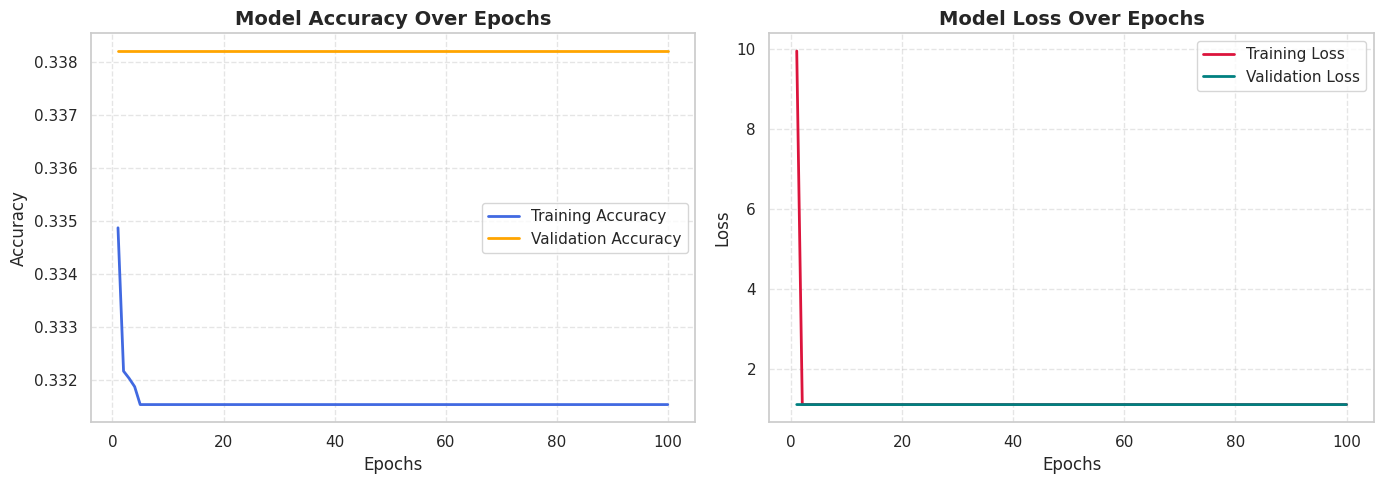

In [40]:
# Extract accuracy and loss
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy', color='royalblue', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss', color='crimson', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='teal', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [41]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('cat', CatBoostClassifier(verbose=0, random_state=42)),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
    ],
    voting='soft'  # 'soft' uses predicted probabilities, better for multi-class
)

voting_clf.fit(X_train, y_train)

y_pred = voting_clf.predict(X_test)

# Accuracy
print(f"Voting Classifier Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Voting Classifier Accuracy: 0.4408

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.44      0.44      3754
           1       0.44      0.44      0.44      3617
           2       0.44      0.44      0.44      3729

    accuracy                           0.44     11100
   macro avg       0.44      0.44      0.44     11100
weighted avg       0.44      0.44      0.44     11100


Confusion Matrix:
[[1653 1027 1074]
 [1028 1599  990]
 [1076 1012 1641]]


**What is Voting Classifier?**

A Voting Classifier is an ensemble model that combines multiple different classifiers to make a final prediction by aggregating their individual outputs. It works by collecting predictions from each base model and then deciding the final class either by majority vote (hard voting) or by averaging predicted probabilities (soft voting). This approach leverages the strengths of various models, often improving accuracy and robustness compared to using a single classifier alone.

In [42]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model_2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history_2 = model_2.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), callbacks=[callback])

Epoch 1/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3334 - loss: 174.0216 - val_accuracy: 0.3284 - val_loss: 19.1339
Epoch 2/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3314 - loss: 31.1004 - val_accuracy: 0.3402 - val_loss: 16.1430
Epoch 3/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3334 - loss: 28.0430 - val_accuracy: 0.3278 - val_loss: 16.9893
Epoch 4/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3365 - loss: 22.6086 - val_accuracy: 0.3388 - val_loss: 21.3020
Epoch 5/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3288 - loss: 21.9644 - val_accuracy: 0.3349 - val_loss: 24.0432
Epoch 6/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3356 - loss: 16.2248 - val_accuracy: 0.3284 - val_loss: 11.4340
Epoch 7/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3360 - loss: 15.8636 - val_accuracy: 0.3356 - val_loss: 8.2716
Epoch 8/20
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3331 - l

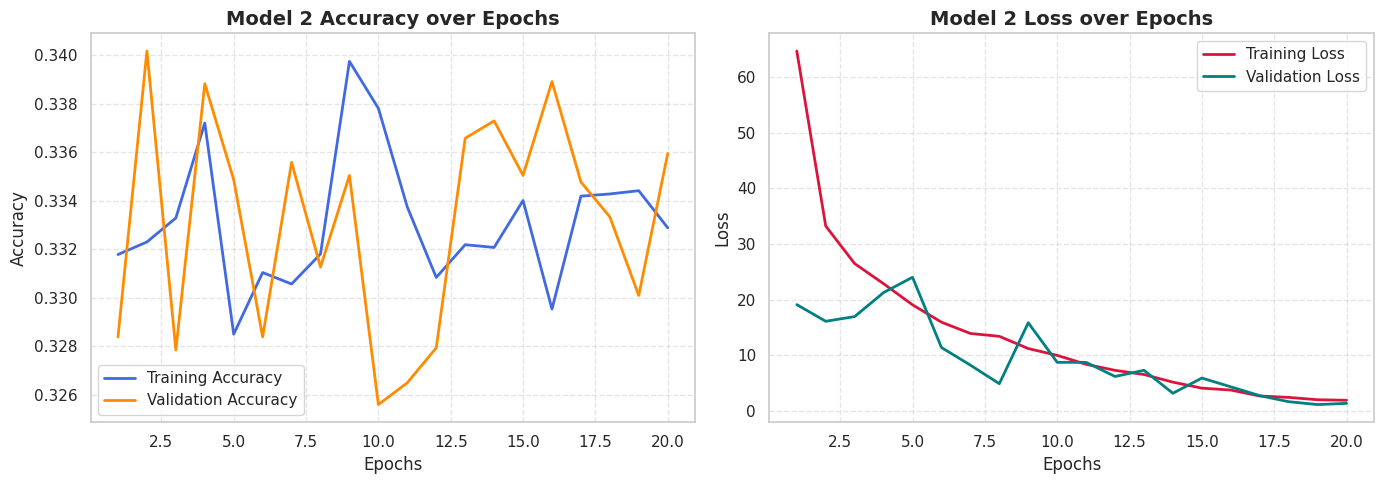

In [43]:
# Extract values
acc = history_2.history['accuracy']
val_acc = history_2.history['val_accuracy']
loss = history_2.history['loss']
val_loss = history_2.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy', color='royalblue', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='darkorange', linewidth=2)
plt.title('Model 2 Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss', color='crimson', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='teal', linewidth=2)
plt.title('Model 2 Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [44]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_3 = model_3.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, callbacks=[callback])

Epoch 1/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3278 - loss: 144.6795 - val_accuracy: 0.3361 - val_loss: 2.2775
Epoch 2/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3385 - loss: 2.6360 - val_accuracy: 0.3379 - val_loss: 1.1793
Epoch 3/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3272 - loss: 1.5677 - val_accuracy: 0.3357 - val_loss: 1.1853
Epoch 4/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3294 - loss: 1.2270 - val_accuracy: 0.3344 - val_loss: 1.0998
Epoch 5/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3350 - loss: 1.1329 - val_accuracy: 0.3358 - val_loss: 1.1136
Epoch 6/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3303 - loss: 1.1213 - val_accuracy: 0.3259 - val_loss: 1.1026
Epoch 7/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3319 - loss: 1.1014 - val_accuracy: 0.3241 - val_loss: 1.0988
Epoch 8/100
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3328 - loss:

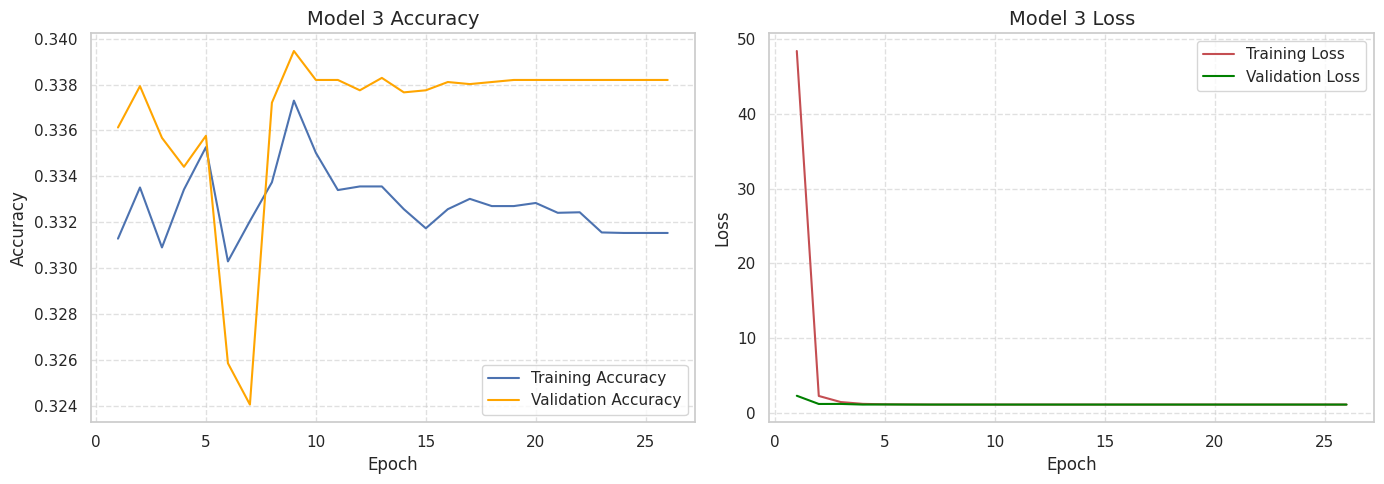

In [45]:
# Extract training history
acc = history_3.history['accuracy']
val_acc = history_3.history['val_accuracy']
loss = history_3.history['loss']
val_loss = history_3.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plotting
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'orange', label='Validation Accuracy')
plt.title('Model 3 Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r-', label='Training Loss')
plt.plot(epochs, val_loss, 'green', label='Validation Loss')
plt.title('Model 3 Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [46]:
y_train.value_counts(normalize=True)

Test Results
0               0.334977
2               0.333063
1               0.331959
Name: proportion, dtype: float64

### About the Dataset and Accuracy

This synthetic healthcare dataset is designed to mimic real-world medical data, which often contains noise and complex patterns. Due to this complexity and the possibly weak relationships between features and the target, the highest accuracy achieved so far is around **44% (Random Forest Classifier Accuracy: 0.4412)**.

Low accuracy is expected here because:

* The data is synthetic, containing noisy or subtle patterns.
* The features do not strongly predict the target without advanced preprocessing.

This dataset is ideal for practicing data preprocessing, modeling, and evaluation rather than expecting high accuracy.